# Task 4: Predicting Insurance Claim Amounts

## Objective
The goal of this task is to predict medical insurance claim charges based on personal
attributes such as age, BMI, and smoking status. This analysis uses a Linear Regression
model to understand how different factors influence insurance costs.

The task also involves exploratory data analysis (EDA) and evaluation of the model using
error metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")


In [11]:
%matplotlib inline

In [4]:
df = pd.read_csv("data/insurance.csv")

## Dataset Understanding

In this step, we explore the structure of the medical insurance dataset by examining
its shape, column names, and a preview of the first few rows. This helps in understanding
the number of records, available features, and the target variable.


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
df.head()

Dataset Shape:
(1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

First 5 Rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Cleaning & Preparation

In this step, we check for missing values and prepare the dataset for modeling.
We will identify feature columns (X) and the target column (y), which is 'charges'.


In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [18]:
X = df[['age', 'bmi', 'smoker']].copy()  # make a copy here
y = df['charges']

# Encode 'smoker' correctly
X['smoker'] = X['smoker'].map({'yes': 1, 'no': 0})

X.head()

,age,bmi,smoker
0,19,27.900,1
1,18,33.770,0
2,28,33.000,0
3,33,22.705,0
4,32,28.880,0


## Encoding Categorical Feature

The 'smoker' column is categorical (yes/no). We need to convert it into numerical form
for the Linear Regression model.


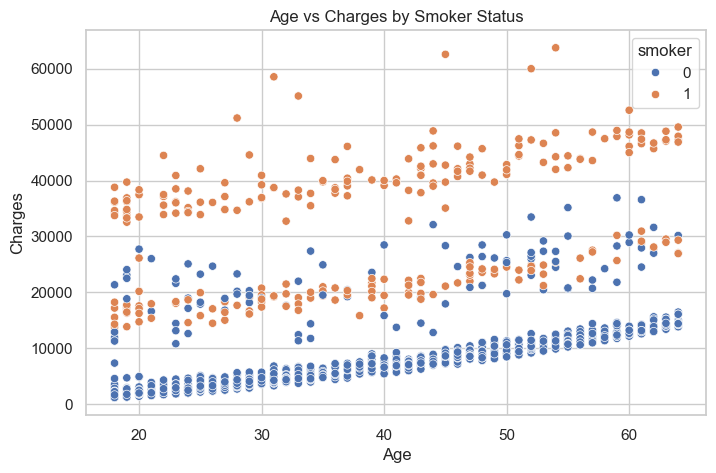

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X['age'], y=y, hue=X['smoker'])
plt.title('Age vs Charges by Smoker Status')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


### BMI vs Charges

We examine how Body Mass Index (BMI) affects insurance charges. 
Scatter plots help us understand whether higher BMI is associated with higher charges.



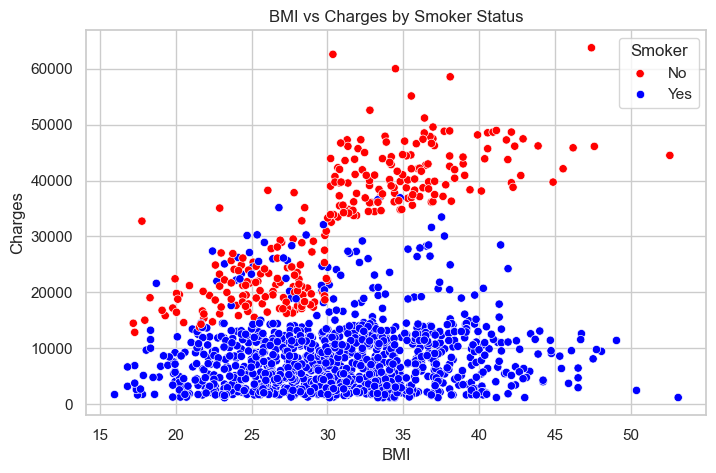

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X['bmi'], y=y, hue=X['smoker'], palette={0:'blue',1:'red'})
plt.title('BMI vs Charges by Smoker Status')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker', labels=['No','Yes'])
plt.show()


### Smoker vs Charges

A box plot is used to visualize the distribution of insurance charges for smokers
and non-smokers. This helps detect differences in spread, median, and potential outliers.

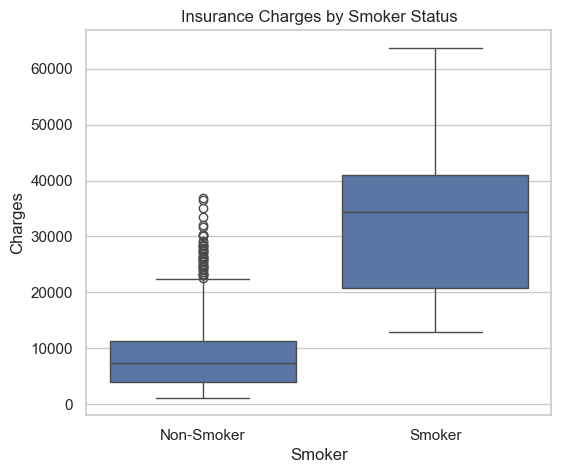

In [22]:
plt.figure(figsize=(6,5))
sns.boxplot(x=X['smoker'], y=y)
plt.xticks([0,1], ['Non-Smoker','Smoker'])
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()


## Linear Regression Model

In this step, we train a Linear Regression model to predict insurance charges
based on age, BMI, and smoker status. We then evaluate the model using
Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).


In [23]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


In [24]:
# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Absolute Error (MAE): 4260.56
Root Mean Squared Error (RMSE): 5874.76


## Conclusion

- Insurance charges are influenced strongly by age, BMI, and especially smoker status.
- Scatter plots showed that smokers consistently have higher charges, and BMI also correlates with cost.
- Linear Regression model achieved MAE ≈ 4260 and RMSE ≈ 5875, giving a reasonable estimation of charges.
- The dataset was clean, and no missing values were present, so minimal data preprocessing was required.
